# CIFAR-10 - Fully Connected Network (FCN)

In [ ]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

import keras
from keras import layers

import numpy as np
import matplotlib.pyplot as plt

In [53]:
# Creating the FCN model: 
inputs = keras.Input(shape=(32, 32, 3))
x = layers.Flatten()(inputs)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dense(128, activation="relu")(x)
outputs = layers.Dense(10, activation="softmax")(x)

model = keras.Model(inputs=inputs, outputs=outputs, name="cifar10_fcn")

In [54]:
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data() # load the cifar-10 dataset

y_train = y_train.flatten()
y_test = y_test.flatten()

# Normalize pixel values to [0, 1]
x_train = x_train.astype("float32") / 255
x_test = x_test.astype("float32") / 255

model.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(),
    optimizer=keras.optimizers.Adam(),
    metrics=["accuracy"],
)

model.summary()

# Training the model
history = model.fit(x_train, y_train, batch_size=32, epochs=20, validation_split=0.2)

Model: "cifar10_fcn"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_9 (InputLayer)        [(None, 32, 32, 3)]       0         
                                                                 
 flatten_2 (Flatten)         (None, 3072)              0         
                                                                 
 dense_24 (Dense)            (None, 256)               786688    
                                                                 
 dense_25 (Dense)            (None, 128)               32896     
                                                                 
 dense_26 (Dense)            (None, 10)                1290      
                                                                 
Total params: 820874 (3.13 MB)
Trainable params: 820874 (3.13 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Epoch 1/20
1250/125

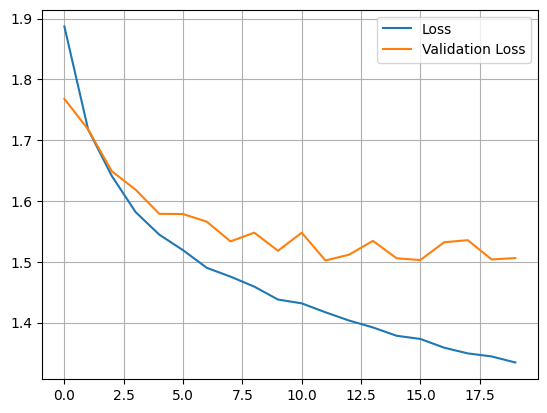

In [55]:
# Plot training and validation loss per epoch
plt.plot(history.history["loss"], label="Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.legend()
plt.grid()
plt.show()

In [56]:
# Evaluate final model on unseen test data
test_scores = model.evaluate(x_test, y_test, verbose=2)
print("Test loss:", test_scores[0])
print("Test accuracy:", test_scores[1])

313/313 - 0s - loss: 1.4848 - accuracy: 0.4744 - 429ms/epoch - 1ms/step
Test loss: 1.484831690788269
Test accuracy: 0.47440001368522644


313/313 [==============================] - 0s 745us/step


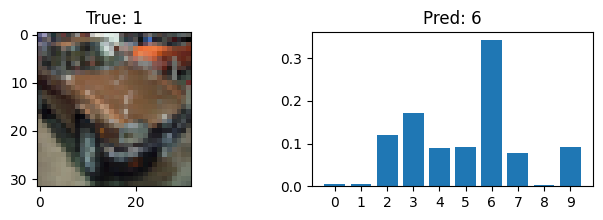

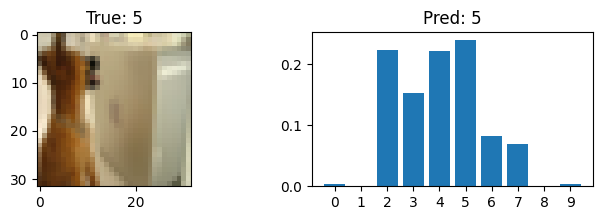

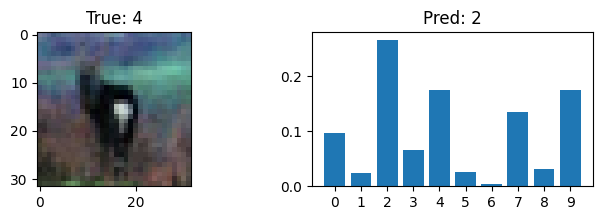

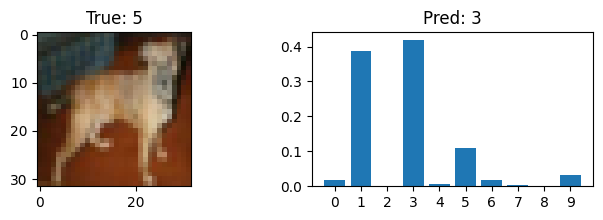

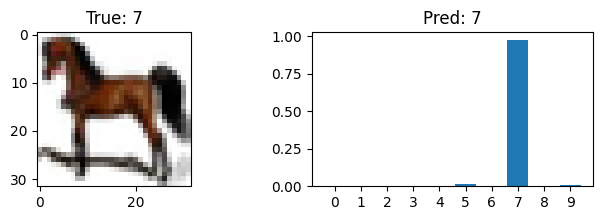

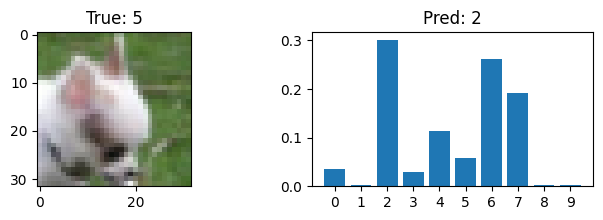

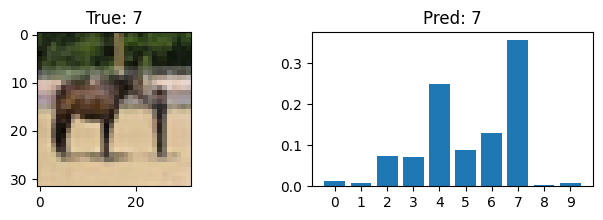

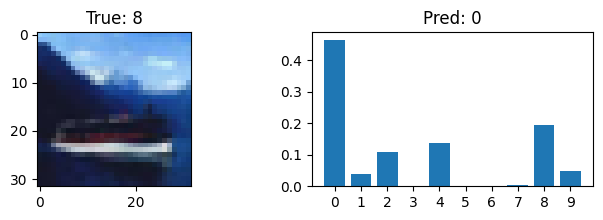

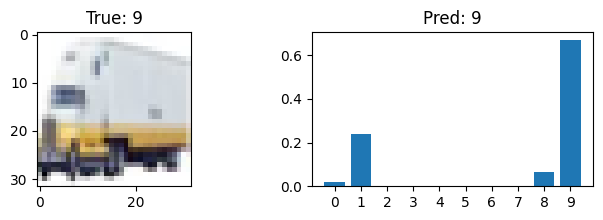

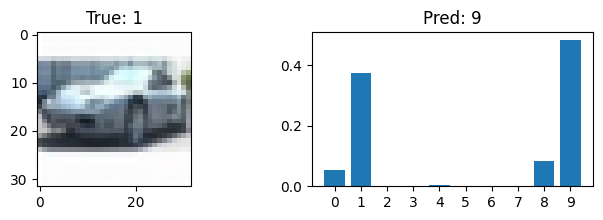

In [57]:
y_pred = model.predict(x_test)
start = 2000

# visualization
for k in range(10):
    plt.figure(figsize=(8, 2))

    plt.subplot(1,2,1)
    plt.imshow(x_test[start+k])
    plt.title(f"True: {y_test[start+k]}")

    plt.subplot(1,2,2)
    plt.bar(range(10), y_pred[start+k].flatten())
    plt.title(f"Pred: {np.argmax(y_pred[start+k])}")

    plt.xticks(range(10))
    plt.show()